In [15]:
from typing import TypedDict

class conversion (TypedDict):
    kilogram : float
    gram : float

In [16]:
def kilogram_from_gram (state:conversion) -> conversion:
    state ['kilogram'] = state['gram']/1000
    return state

In [17]:
def gram_from_kilogram (state : conversion) -> conversion :
    state ['gram'] = state['kilogram'] *1000
    return state

In [18]:
from langgraph.graph import StateGraph , START , END

builder = StateGraph(conversion)

builder.add_node("kilo-from-gram" , kilogram_from_gram)
builder.add_node("gram-from-kilo" , gram_from_kilogram)

builder.add_edge(START , 'kilo-from-gram')
builder.add_edge('kilo-from-gram' , "gram-from-kilo" )
builder.add_edge("gram-from-kilo", END)

graph = builder.compile()

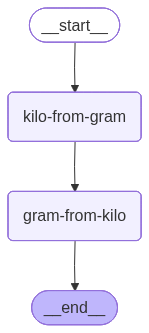

In [19]:
from IPython.display import Image , display

display(Image(graph.get_graph().draw_mermaid_png()))